In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
path = os.getcwd()
import sys
from os.path import join as pjoin
from pathlib import Path
import numpy as np
import rioxarray
import numpy as np
import joblib
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.cluster._kmeans')

gmm = joblib.load("..\\models\\gmm_B(2022,2023)_k10_init3_MS_median_bathy_11F.pkl")
kmeans = joblib.load("..\\models\\kmeans_B(2022,2023)_kmeans10_MS_median_bathy.pkl")

# Get project root to allow for relative imports
notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent

print(f"Project root: {project_root}")

# Add PROJECT ROOT to sys.path
sys.path.insert(0, str(project_root))

from scripts.features import prepare_data
# from scripts import model as M
from scripts.data_loading import compute_bands_all
from scripts import cache
from scripts import config 

Project root: c:\Users\denni\OneDrive\Documenten\ADS\Spatial Simulation Modelling\Project\RemoteSensing_CoralReefs


c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
tiff_path = "..//data//raw//PSScene//20240607_000749_84_24e5_3B_AnalyticMS_SR_8b_clip_philip.tif"
band = rioxarray.open_rasterio(tiff_path)
data_monthly_other = np.load("..//data//interim//monthly_data_B(2022,2023)_k10_init3_MS_median_bathy_11F.npy")
labels_monthly_other = np.load("..//data//interim//predictions_monthly_B(2022,2023)_k10_init3_MS_median_bathy_11F_labels.npy")
mask_monthly_other = np.load("..//data//interim//monthly_data_B(2022,2023)_k10_init3_MS_median_bathy_11F_mask.npy")

Below reads in data which has been produced by the validation_GMM and validation_KMeans script respectively

In [10]:
import pandas as pd
df_gmm = pd.read_parquet("..//data//processed//validation_results//bootstrap_mean_results_GMM.parquet")
df_gmm_ari = pd.read_parquet("..//data//processed//validation_results//ari_results_GMM.parquet")
df_kmeans = pd.read_parquet("..//data//processed//validation_results//bootstrap_mean_results_KMeans.parquet")
df_kmeans_ari = pd.read_parquet("..//data//processed//validation_results//ari_results_KMeans.parquet")
df_kmeans["Date"] = df_gmm["Date"].to_list()
df_kmeans_ari["Date"] = df_gmm["Date"].to_list()
df_gmm["clustering"] = "GMM"
df_kmeans["clustering"] = "KMeans"
df_gmm_ari["clustering"] = "GMM"
df_kmeans_ari["clustering"] = "KMeans"
df = pd.concat([df_gmm, df_kmeans])
df_ari = pd.concat([df_gmm_ari, df_kmeans_ari])


# Computing bootstrapped means

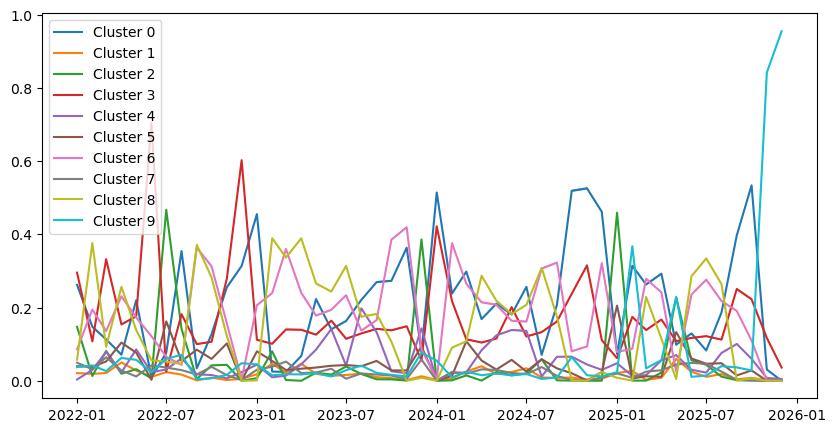

In [3]:
# sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
means_gmm = np.vstack(df_gmm["mean"])
lowers_gmm = np.vstack(df_gmm["lower"])
uppers_gmm = np.vstack(df_gmm["upper"])
Date_gmm = np.vstack(df_gmm["Date"])

for k in range(means_gmm.shape[1]):
    plt.plot(Date_gmm, means_gmm[:, k], label=f"Cluster {k}")
    plt.fill_between(Date_gmm[:,0], lowers_gmm[:, k], uppers_gmm[:, k], alpha=0.5)

plt.legend()
plt.show()

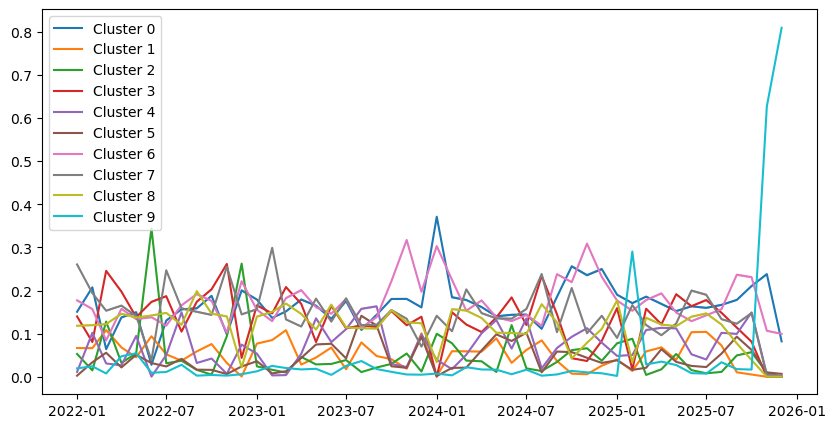

In [4]:
# sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
means_kmeans = np.vstack(df_kmeans["mean"])
lowers_kmeans = np.vstack(df_kmeans["lower"])
uppers_kmeans = np.vstack(df_kmeans["upper"])
Date_kmeans = np.vstack(df_kmeans["Date"])

for k in range(means_kmeans.shape[1]):
    plt.plot(Date_kmeans, means_kmeans[:, k], label=f"Cluster {k}")
    plt.fill_between(Date_kmeans[:,0], lowers_kmeans[:, k], uppers_kmeans[:, k], alpha=0.5)

plt.legend()
plt.show()

# Bootstrapped mean potential coral-cluster

Below is the proportion plotted from one cluster together with the bootstrap 95%-CI over time. 

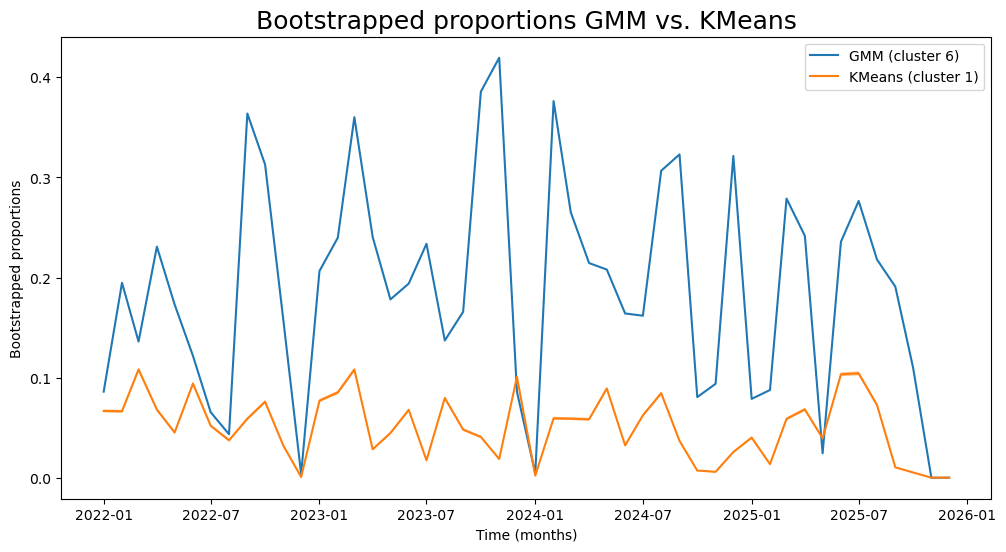

In [71]:

cluster_no = 6
sns.reset_defaults()
plt.figure(figsize=(12, 6))
plt.plot(Date_gmm, means_gmm[:, cluster_no], label=f"GMM (cluster {cluster_no})")
plt.fill_between(Date_gmm[:,0], lowers_gmm[:, cluster_no], lowers_gmm[:, cluster_no], alpha=0.5)

cluster_no = 1
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(10, 5))
plt.plot(Date_kmeans, means_kmeans[:, cluster_no], label=f"KMeans (cluster {cluster_no})",)
plt.fill_between(Date_kmeans[:,0], lowers_kmeans[:, cluster_no], uppers_kmeans[:, cluster_no], alpha=0.5)
plt.xlabel("Time (months)")
plt.ylabel("Bootstrapped proportions")
plt.legend()
plt.title("Bootstrapped proportions GMM vs. KMeans", fontsize=18)

plt.show()

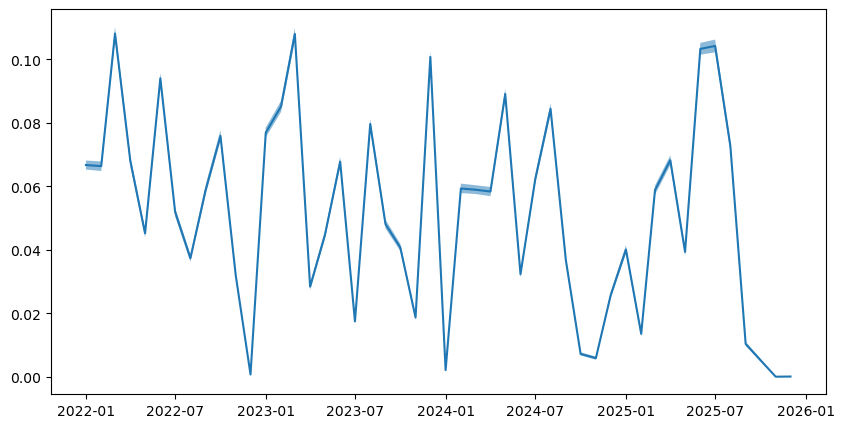

In [7]:
cluster_no = 1
# sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.plot(Date_kmeans, means_kmeans[:, cluster_no], label=f"Cluster {cluster_no}")
plt.fill_between(Date_kmeans[:,0], lowers_kmeans[:, cluster_no], uppers_kmeans[:, cluster_no], alpha=0.5)
plt.show()

# Computing Silhouette score

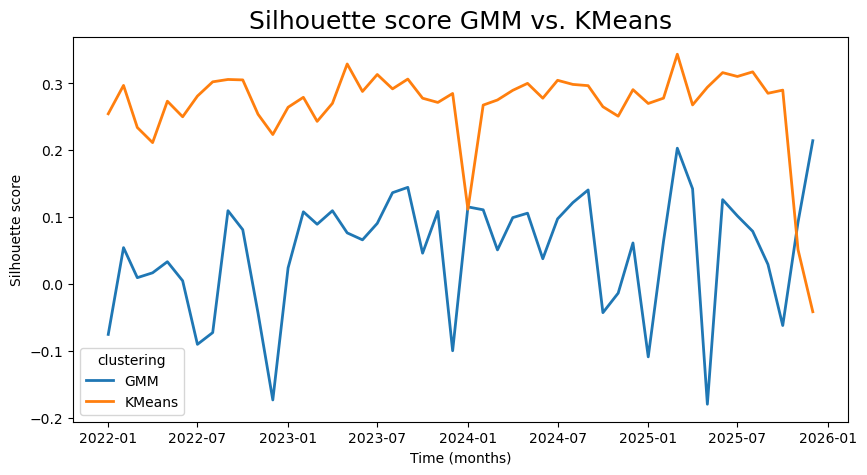

In [41]:
import seaborn as sns
plt.figure(figsize=(10, 5))

sns.lineplot(x=df["Date"], y=df["silhouette_score"], hue=df["clustering"], linewidth=2)
plt.title("Silhouette score GMM vs. KMeans", fontsize=18)
plt.xlabel("Time (months)")
plt.ylabel("Silhouette score")
plt.show()

# Compute ARI-score

In [ ]:
# df_ari_GMM = pd.read_parquet("..//data//processed//validation_results//ari_results_GMM.parquet")
# df_ari_GMM["clustering"] = "GMM"
# df_ari_Kmeans = pd.read_parquet("..//data//processed//validation_results//ari_results_Kmeans.parquet")
# df_ari_Kmeans["clustering"] = "KMeans"
# df_ari = pd.concat([df_ari_GMM, df_ari_Kmeans])

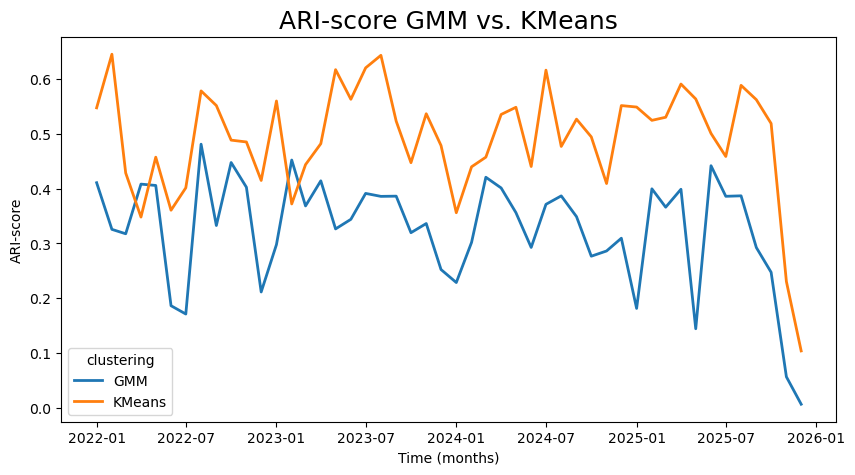

In [46]:
import seaborn as sns
plt.figure(figsize=(10, 5))

sns.lineplot(x=df_ari["Date"], y=df_ari["mean"], hue=df_ari["clustering"], linewidth=2)
plt.title("ARI-score GMM vs. KMeans", fontsize=18)
plt.xlabel("Time (months)")
plt.ylabel("ARI-score")
plt.show()

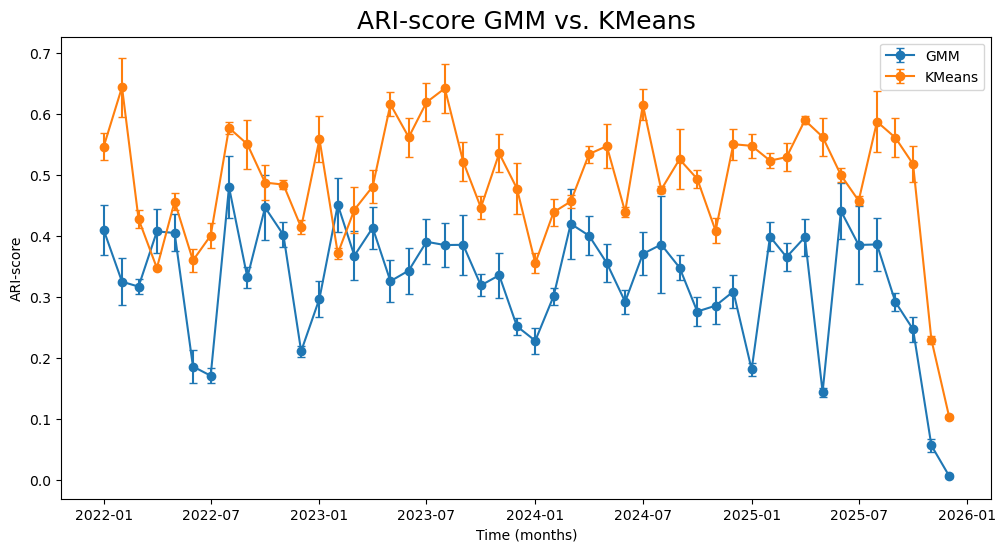

In [64]:
plt.figure(figsize=(12, 6))

plt.errorbar(
    x=df_gmm_ari["Date"], 
    y=df_gmm_ari["mean"].tolist(), 
    yerr=df_gmm_ari["stdev"].tolist(),
    marker='o',
    linestyle='-',
    capsize=3
)

plt.errorbar(
    x=df_kmeans_ari["Date"], 
    y=df_kmeans_ari["mean"].tolist(), 
    yerr=df_kmeans_ari["stdev"].tolist(),
    marker='o',
    linestyle='-',
    capsize=3,
)
plt.title("ARI-score GMM vs. KMeans", fontsize=18)
# plt.grid(alpha=0.3)
plt.xlabel("Time (months)")
plt.ylabel("ARI-score")
plt.legend(["GMM", "KMeans"])
plt.show()